# 24. Contract personalization contour v6.2

Новый end-to-end контур персонализации в `z_contract` с dB-aware метриками.

Версия v6.2 добавляет plateau-aware late routing для `phase_mixed_contract_v6`:

- warmup через `candidate_pool_contract` короче;
- semantic backbone длится дольше;
- после soft-stop marker semantic остаётся основным источником, пока расстояние продолжает уменьшаться;
- `axis_contract` и `candidate_pool_contract` используются как редкие probes;
- после soft-stop marker `direct_trust_contract` включается не постоянно, а только периодически;
- на convergence-графики добавлен вертикальный soft-stop marker.

> This notebook is a separate v6.2 snapshot; notebook 22 is left as the generic v6 contour notebook.


In [1]:

from personalization.plotting import use_article_style
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
TABLES_DIR = OUTPUT_DIR / "tables"
for p in [FIGURES_DIR, METRICS_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.state import FEATURE_NAMES_8D
from personalization.contract_space import (
    DEFAULT_CONTRACT_SCALE,
    CONTRACT_ARCHETYPES_8D,
    archetype_table,
    contract_scale_table,
    make_axis_sweep_contract,
    z_contract_series,
)
from personalization.contract_mapper import InterpretableContractMapper8D, FREQS_23_DEFAULT
from personalization.contract_metrics import curve_metrics, mapped_pair_metrics, mapped_distance_to_target


def plot_eq_curves(curves, freqs=FREQS_23_DEFAULT, title=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    for label, curve in curves.items():
        ax.plot(freqs, curve, marker="o", linewidth=1.6, label=label)
    ax.axhline(0, linewidth=1, alpha=0.35)
    ax.set_xscale("log")
    ax.set_xticks(freqs)
    ax.set_xticklabels([f"{f:g}" for f in freqs], rotation=45, ha="right")
    ax.set_xlabel("Frequency, Hz")
    ax.set_ylabel("Gain, dB")
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


def savefig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)

from personalization.synthetic_dataset import generate_synthetic_users_dataset
from personalization.contract_pair_generator import ContractPairConfig
from personalization.contract_session import (
    ContractSessionConfig,
    run_contract_comparison_on_dataset,
    contract_records_dataframe,
    contract_summary_dataframe,
)

use_article_style()



## Generate / load synthetic users

Цели синтетических пользователей лежат в `[-2, 2]` и трактуются как contract-space.

In [2]:
SEED = 42
N_PER_MODE = 40

dataset = generate_synthetic_users_dataset(
    n_per_mode=N_PER_MODE,
    seed=SEED,
    noise_std=0.03,
    target_max_abs=2.0,
    archetype_extreme_probability=0.35,
)

dataset.to_csv(TABLES_DIR / "v6_2_contract_synthetic_users.csv", index=False)
print("rows:", len(dataset))
dataset["target_mode"].value_counts()

rows: 160


target_mode
random8d       40
semantic4d     40
semantic6d     40
archetype8d    40
Name: count, dtype: int64

## Run comparison

`phase_mixed_contract_v6` теперь отличается от semantic baseline, но v6.2 уходит в direct/refinement только после локального плато:

- steps 1–3: `candidate_pool_contract`;
- steps 4–17: `semantic_contract`;
- после 17 шага: semantic по умолчанию; direct/axis/candidate включаются только если последние шаги почти не дают выигрыша;
- после soft-stop marker: sparse `direct_trust_contract`, а не полный переход в direct.

Цель: сохранить безопасность phase-подхода по `max_abs_db`, но не потерять сходимость относительно semantic baseline.

In [3]:
mapper = InterpretableContractMapper8D(freqs_hz=FREQS_23_DEFAULT, safety=True)

pair_cfg = ContractPairConfig(
    step_scale=0.46,
    max_pair_distance_z=1.25,
    min_pair_distance_z=0.14,
    max_pair_distance_db_rms=6.8,
    max_candidate_abs_db=12.5,
)

SESSION_KWARGS = dict(
    # Slightly stricter marker; phase uses it only as a permission for sparse direct probes.
    min_ready_step=16,
    ready_mean_std_threshold=0.60,
    ready_update_norm_threshold=0.25,
    ready_distance_z_threshold=0.90,
    ready_distance_db_rms_threshold=1.55,
    ready_distance_step_window=4,
    ready_min_gain_z=0.035,
    ready_min_gain_db_rms=0.08,

    # v6.2 phase schedule.
    phase_warmup_steps=3,
    phase_semantic_until_step=17,
    phase_axis_every=5,
    phase_candidate_pool_every=7,

    # Plateau-aware late routing: keep semantic if recent progress is still visible.
    post_marker_use_direct=True,
    post_marker_probe_window=3,
    post_marker_probe_min_gain_z=0.025,
    post_marker_probe_min_gain_db_rms=0.070,
    post_marker_semantic_probability=0.70,
    post_marker_direct_probability=0.20,
    post_marker_axis_probability=0.07,
    post_marker_candidate_pool_probability=0.03,
    direct_mode="trust",
)

MAX_USERS = 80

results = run_contract_comparison_on_dataset(
    dataset,
    strategies=["semantic_contract_v6", "phase_mixed_contract_v6"],
    n_steps=25,
    seed=SEED,
    mapper=mapper,
    max_users=MAX_USERS,
    pair_config=pair_cfg,
    session_kwargs=SESSION_KWARGS,
)

len(results)

160

## Summary

In [4]:
summary = contract_summary_dataframe(results)
records = contract_records_dataframe(results)

summary.to_csv(METRICS_DIR / "v6_2_contract_session_summary.csv", index=False)
records.to_csv(METRICS_DIR / "v6_2_contract_session_steps.csv", index=False)

summary_by_group = summary.groupby(["strategy", "target_mode"]).agg(
    users=("final_distance_z", "size"),
    mean_final_distance_z=("final_distance_z", "mean"),
    mean_final_distance_db_rms=("final_distance_db_rms", "mean"),
    mean_ready_step=("ready_step", "mean"),
    ready_rate=("ready_step", lambda s: float(s.notna().mean())),
    mean_extra_gain_db_after_ready=("extra_gain_db_after_ready", "mean"),
    mean_final_max_abs_db=("final_mapped_max_abs_db", "mean"),
).reset_index()

summary_by_group.to_csv(TABLES_DIR / "v6_2_contract_summary_by_target.csv", index=False)
summary_by_group

,strategy,target_mode,users,mean_final_distance_z,mean_final_distance_db_rms,mean_ready_step,ready_rate,mean_extra_gain_db_after_ready,mean_final_max_abs_db
0,phase_mixed_contract_v6,archetype8d,16,0.327931,0.521875,16.125000,1.000000,0.212662,4.525770
1,phase_mixed_contract_v6,random8d,24,1.369522,1.683612,17.318182,0.916667,0.156166,6.640747
2,phase_mixed_contract_v6,semantic4d,18,0.386185,0.791240,16.529412,0.944444,0.306964,7.996429
3,phase_mixed_contract_v6,semantic6d,22,0.613833,1.278632,17.315789,0.863636,0.410621,9.103456
4,semantic_contract_v6,archetype8d,16,0.305144,0.438236,16.125000,1.000000,0.410081,4.753071
5,semantic_contract_v6,random8d,24,1.354788,1.607386,17.619048,0.875000,0.121230,6.822031
6,semantic_contract_v6,semantic4d,18,0.357965,0.673334,16.777778,1.000000,0.423310,8.275506
7,semantic_contract_v6,semantic6d,22,0.566364,1.108972,17.055556,0.818182,0.500897,9.445919


## Source usage

Эта диагностика проверяет, что `phase_mixed_contract_v6` больше не является тем же semantic baseline.

In [5]:
source_usage = (
    records
    .groupby(["strategy", "pair_source_group"])
    .size()
    .reset_index(name="questions")
)
source_usage["share_pct"] = source_usage.groupby("strategy")["questions"].transform(lambda s: 100 * s / s.sum())
source_usage.to_csv(TABLES_DIR / "v6_2_contract_pair_source_usage.csv", index=False)
source_usage.sort_values(["strategy", "questions"], ascending=[True, False])

,strategy,pair_source_group,questions,share_pct
3,phase_mixed_contract_v6,semantic_contract,1679,83.95
1,phase_mixed_contract_v6,candidate_pool_contract,256,12.80
0,phase_mixed_contract_v6,axis_contract,35,1.75
2,phase_mixed_contract_v6,direct_trust_contract,30,1.50
4,semantic_contract_v6,semantic_contract,2000,100.00


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_source_usage_by_step_phase_mixed_contract_v6.png


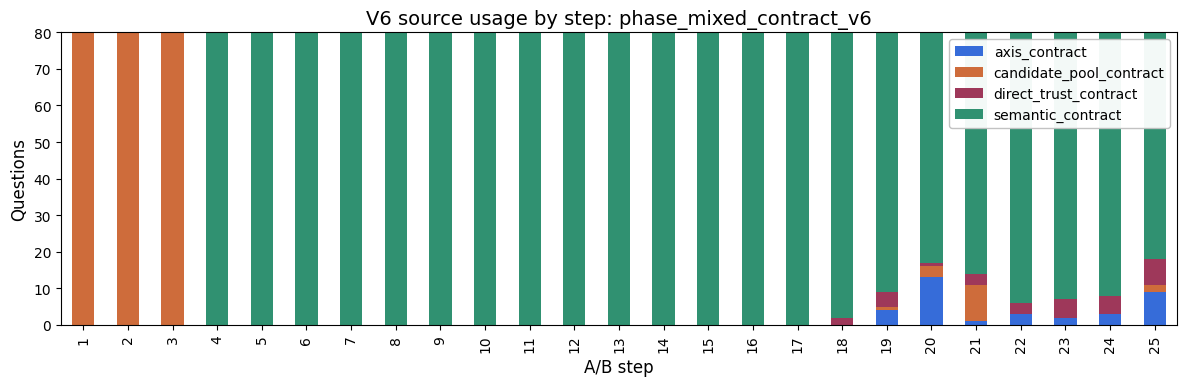

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_source_usage_by_step_semantic_contract_v6.png


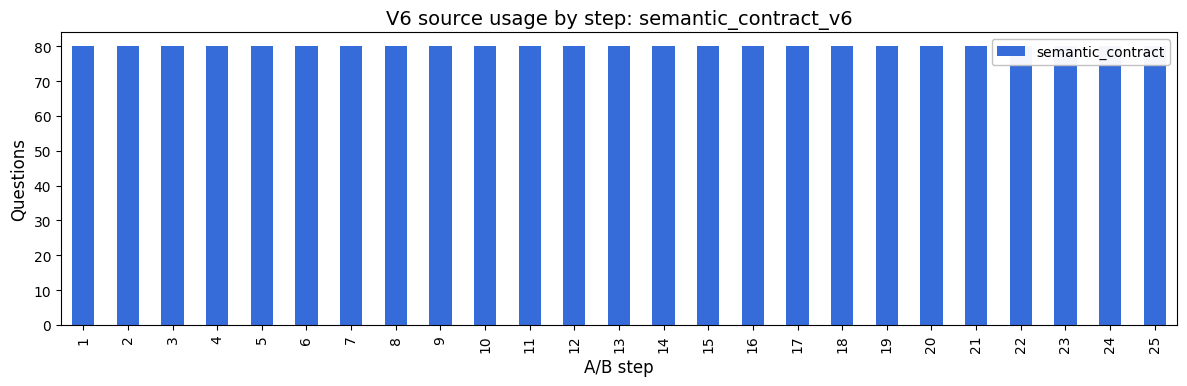

In [6]:
step_source = (
    records
    .groupby(["strategy", "step", "pair_source_group"])
    .size()
    .reset_index(name="questions")
)

for strategy, g in step_source.groupby("strategy"):
    pivot_source = g.pivot_table(
        index="step",
        columns="pair_source_group",
        values="questions",
        aggfunc="sum",
        fill_value=0,
    )
    ax = pivot_source.plot(kind="bar", stacked=True, figsize=(12, 4))
    ax.set_title(f"V6 source usage by step: {strategy}")
    ax.set_xlabel("A/B step")
    ax.set_ylabel("Questions")
    ax.legend(loc="best")
    plt.tight_layout()
    savefig(f"v6_2_contract_source_usage_by_step_{strategy}.png")
    plt.show()

## Convergence plots

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_convergence_distance_z.png


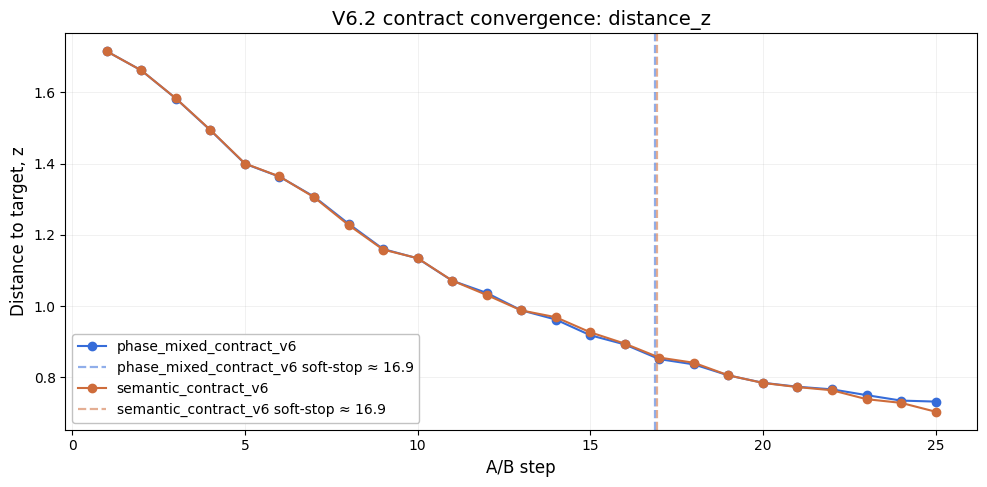

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_convergence_distance_db.png


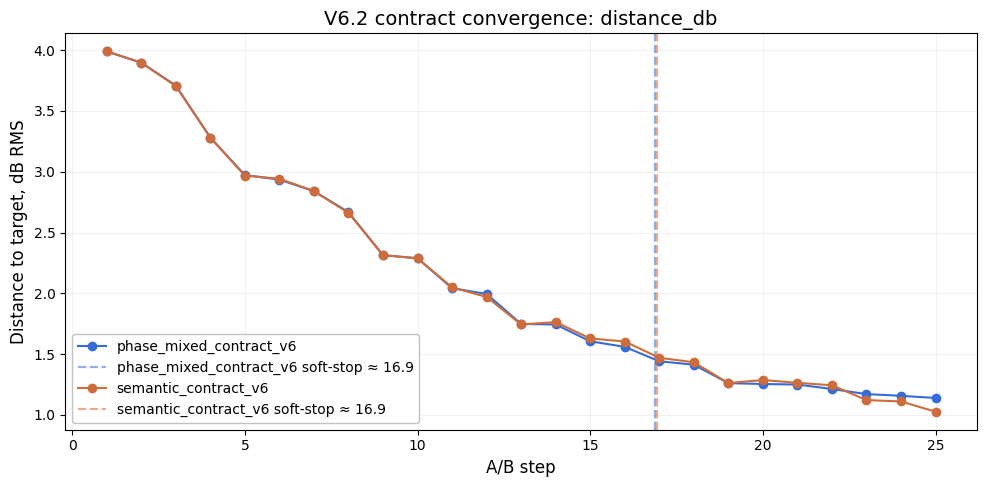

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_convergence_max_abs_db.png


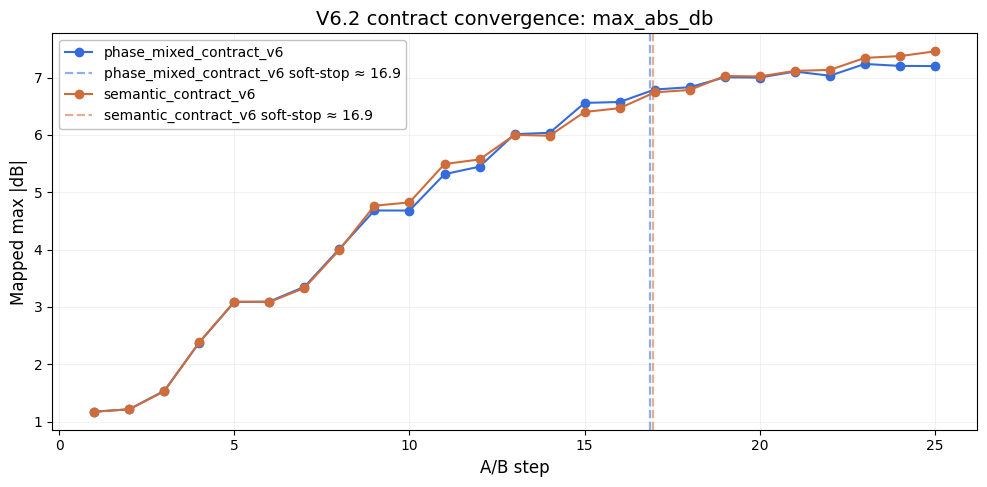

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_convergence_pair_max_abs_db.png


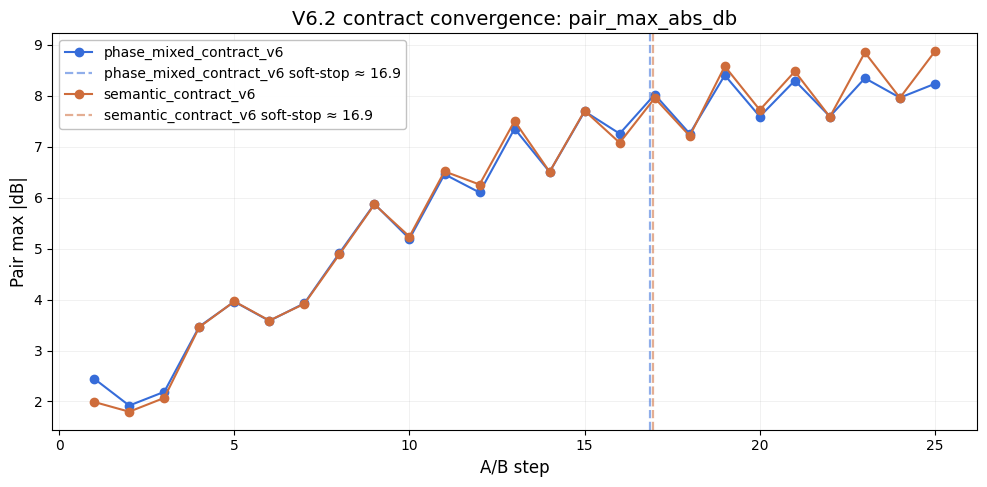

In [7]:
conv = records.groupby(["strategy", "step"]).agg(
    distance_z=("distance_to_target_z", "mean"),
    distance_db=("distance_to_target_db_rms", "mean"),
    max_abs_db=("state_mapped_max_abs_db", "mean"),
    pair_max_abs_db=("pair_max_abs_db", "mean"),
).reset_index()

ready_lines = (
    summary
    .groupby("strategy")["ready_step"]
    .mean()
    .dropna()
    .to_dict()
)

for metric, ylabel in [
    ("distance_z", "Distance to target, z"),
    ("distance_db", "Distance to target, dB RMS"),
    ("max_abs_db", "Mapped max |dB|"),
    ("pair_max_abs_db", "Pair max |dB|"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))

    for strategy, g in conv.groupby("strategy"):
        line, = ax.plot(g["step"], g[metric], marker="o", label=strategy)

        # Mean soft-stop marker for this strategy. This is a marker, not a hard stop:
        # sessions still continue to 25 steps to measure extra gain after marker.
        if strategy in ready_lines:
            marker_step = float(ready_lines[strategy])
            color = line.get_color()
            ax.axvline(
                marker_step,
                color=color,
                linestyle="--",
                linewidth=1.6,
                alpha=0.55,
                label=f"{strategy} soft-stop ≈ {marker_step:.1f}",
            )

    ax.set_xlabel("A/B step")
    ax.set_ylabel(ylabel)
    ax.set_title(f"V6.2 contract convergence: {metric}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    savefig(f"v6_2_contract_convergence_{metric}.png")
    plt.show()

## Soft-stop marker diagnostics

Marker показывает место, где сессию можно было бы завершить. При этом симуляция продолжает идти до 25 шагов, чтобы оценить дополнительный выигрыш после marker.

In [8]:
ready_overview = summary.groupby("strategy").agg(
    users=("final_distance_z", "size"),
    ready_rate=("ready_step", lambda s: float(s.notna().mean())),
    mean_ready_step=("ready_step", "mean"),
    mean_steps_after_ready=("steps_after_ready", "mean"),
    mean_distance_db_at_ready=("distance_db_at_ready", "mean"),
    mean_final_distance_db=("final_distance_db_rms", "mean"),
    mean_extra_gain_db=("extra_gain_db_after_ready", "mean"),
    mean_distance_z_at_ready=("distance_z_at_ready", "mean"),
    mean_final_distance_z=("final_distance_z", "mean"),
    mean_extra_gain_z=("extra_gain_z_after_ready", "mean"),
).reset_index()

ready_overview.to_csv(TABLES_DIR / "v6_2_contract_soft_stop_overview.csv", index=False)
ready_overview

,strategy,users,ready_rate,mean_ready_step,mean_steps_after_ready,mean_distance_db_at_ready,mean_final_distance_db,mean_extra_gain_db,mean_distance_z_at_ready,mean_final_distance_z,mean_extra_gain_z
0,phase_mixed_contract_v6,80,0.9250,16.878378,8.121622,1.293325,1.139111,0.268357,0.780246,0.732138,0.101639
1,semantic_contract_v6,80,0.9125,16.945205,8.054795,1.267328,1.026330,0.352642,0.755922,0.703757,0.108871


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_soft_stop_vs_final_distance.png


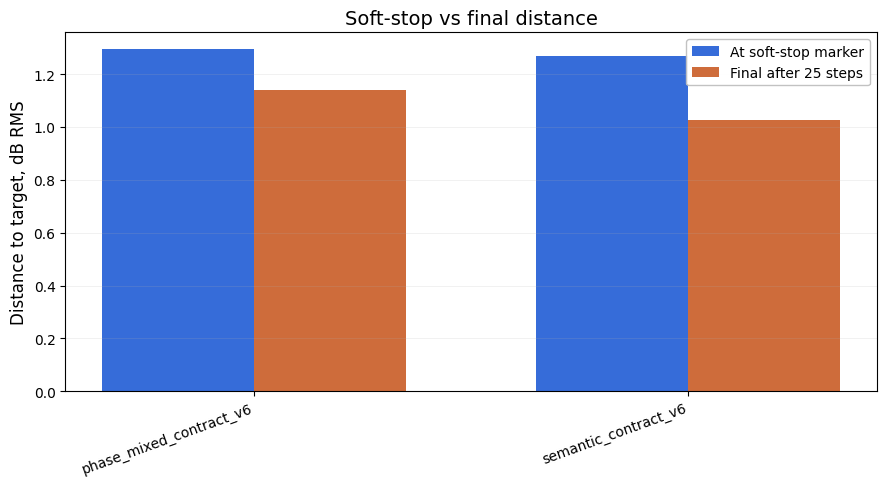

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_2_contract_extra_gain_after_soft_stop.png


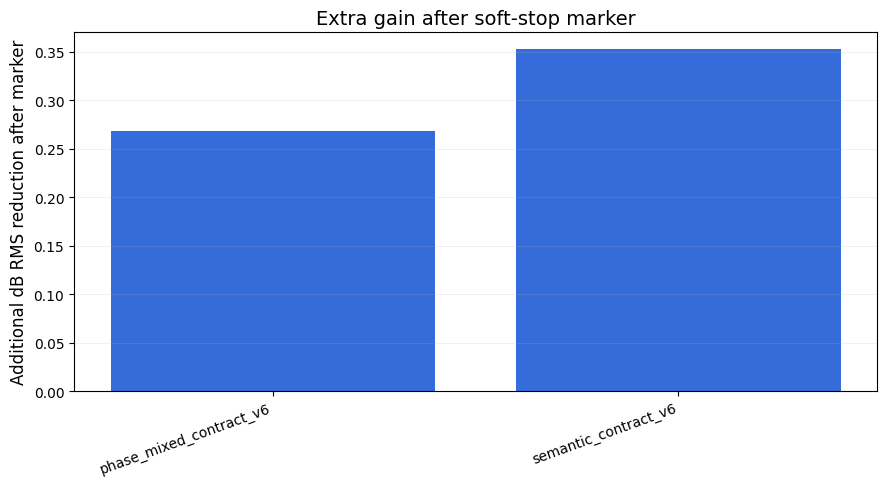

In [9]:
ready_summary = summary[summary["ready_step"].notna()].copy()

if len(ready_summary) > 0:
    # Stop vs final distance.
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(ready_overview))
    width = 0.35
    ax.bar(x - width / 2, ready_overview["mean_distance_db_at_ready"], width, label="At soft-stop marker")
    ax.bar(x + width / 2, ready_overview["mean_final_distance_db"], width, label="Final after 25 steps")
    ax.set_xticks(x)
    ax.set_xticklabels(ready_overview["strategy"], rotation=20, ha="right")
    ax.set_ylabel("Distance to target, dB RMS")
    ax.set_title("Soft-stop vs final distance")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    savefig("v6_2_contract_soft_stop_vs_final_distance.png")
    plt.show()

    # Extra gain after marker.
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(ready_overview["strategy"], ready_overview["mean_extra_gain_db"])
    ax.set_ylabel("Additional dB RMS reduction after marker")
    ax.set_title("Extra gain after soft-stop marker")
    ax.grid(True, axis="y", alpha=0.25)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    savefig("v6_2_contract_extra_gain_after_soft_stop.png")
    plt.show()
else:
    print("No ready markers were triggered. Consider relaxing ready thresholds or checking update_norm/mean_z_std.")

## Final distance by target mode

In [10]:
pivot = summary.pivot_table(
    index="target_mode",
    columns="strategy",
    values="final_distance_db_rms",
    aggfunc="mean",
)
pivot.to_csv(TABLES_DIR / "v6_2_contract_final_distance_db_pivot.csv")
pivot

strategy,phase_mixed_contract_v6,semantic_contract_v6
target_mode,,
archetype8d,0.521875,0.438236
random8d,1.683612,1.607386
semantic4d,0.791240,0.673334
semantic6d,1.278632,1.108972


## Per-strategy quick verdict

In [11]:
verdict = summary.groupby("strategy").agg(
    users=("final_distance_db_rms", "size"),
    final_distance_z=("final_distance_z", "mean"),
    final_distance_db_rms=("final_distance_db_rms", "mean"),
    ready_rate=("ready_step", lambda s: float(s.notna().mean())),
    ready_step=("ready_step", "mean"),
    extra_gain_db_after_ready=("extra_gain_db_after_ready", "mean"),
    final_mapped_max_abs_db=("final_mapped_max_abs_db", "mean"),
).reset_index().sort_values("final_distance_db_rms")

verdict.to_csv(TABLES_DIR / "v6_2_contract_strategy_verdict.csv", index=False)
verdict

,strategy,users,final_distance_z,final_distance_db_rms,ready_rate,ready_step,extra_gain_db_after_ready,final_mapped_max_abs_db
1,semantic_contract_v6,80,0.703757,1.026330,0.9125,16.945205,0.352642,7.456840
0,phase_mixed_contract_v6,80,0.732138,1.139111,0.9250,16.878378,0.268357,7.200025
